In [ ]:
# Monte Carlo Dropout version
# visibility classification problem where obs and model are having separate branches
%tensorflow_version 2.x

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files

import tensorflow as tf

from tensorflow.keras.utils import to_categorical

from tensorflow.keras.layers import Input, Lambda, Dense, Reshape, Flatten, \
    LSTM, Concatenate, Activation, BatchNormalization, TimeDistributed
from tensorflow.keras.models import Model, load_model

from tensorflow.keras import metrics, losses
from tensorflow.keras import backend as K

tf.test.gpu_device_name()
print(tf.__version__)

2.2.0


In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [ ]:
# Load the data
obs_data_vis = np.load('/content/gdrive/My Drive/Colab Notebooks/Visobs.npy', allow_pickle=True)
model_data_vis = np.load('/content/gdrive/My Drive/Colab Notebooks/Vismodel.npy', allow_pickle=True)

obs_data_T = np.load('/content/gdrive/My Drive/Colab Notebooks/Tobs.npy', allow_pickle=True)
model_data_T = np.load('/content/gdrive/My Drive/Colab Notebooks/Tmodel.npy', allow_pickle=True)

obs_data_Td = np.load('/content/gdrive/My Drive/Colab Notebooks/Tdobs.npy', allow_pickle=True)
model_data_Td = np.load('/content/gdrive/My Drive/Colab Notebooks/Tdmodel.npy', allow_pickle=True)

In [ ]:
# Max model visibility data is 9999 so truncate model vis to that
model_data_vis[model_data_vis > np.max(obs_data_vis)] = np.max(obs_data_vis) 

In [ ]:
# Bin the data
bins = [0, 150, 350, 600, 800, 1500, 3000, 5000, 10000]
obs_data_vis = pd.cut(obs_data_vis, bins, labels=[0,1,2,3,4,5,6,7])
model_binned = np.zeros(model_data_vis.shape)
for i in range(4):
  model_binned[i,:] = pd.cut(model_data_vis[i,:], bins, labels=[0,1,2,3,4,5,6,7])
model_data_vis = model_binned

In [ ]:
# Normalize the Td/T data
obs_data_T = (obs_data_T-np.mean(obs_data_T))/np.std(obs_data_T)
obs_data_Td = (obs_data_Td-np.mean(obs_data_Td))/np.std(obs_data_Td)

model_data_T = (model_data_T-np.mean(model_data_T))/np.std(model_data_T)
model_data_Td = (model_data_Td-np.mean(model_data_Td))/np.std(model_data_Td)

In [ ]:
# Use the past_history nr of data to predict future_target nr of data
past_history = 6
future_target = 1

In [ ]:
# Add obs data to model data
dataset = np.concatenate((model_data_vis, np.reshape(obs_data_vis,(1,-1))), axis=0)
dataset_vis = np.swapaxes(dataset,0,1)

dataset = np.concatenate((model_data_T, np.reshape(obs_data_T,(1,-1))), axis=0)
dataset_T = np.swapaxes(dataset,0,1)

dataset = np.concatenate((model_data_Td, np.reshape(obs_data_Td,(1,-1))), axis=0)
dataset_Td = np.swapaxes(dataset,0,1)

dataset_vis.shape

(27001, 5)

In [ ]:
# Split into training data
TRAIN_SPLIT = np.int(0.9*len(dataset_vis))
print(TRAIN_SPLIT)

24300


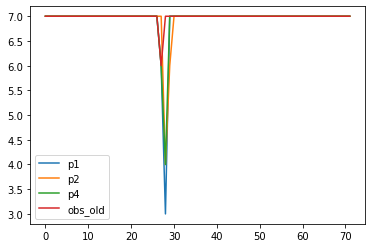

In [ ]:
# Plot part of data to make sure concatenation and normalization was successful
plt.plot(dataset_vis[:72,0])
plt.plot(dataset_vis[:72,1])
plt.plot(dataset_vis[:72,3])
plt.plot(dataset_vis[:72,4])
plt.legend(['p1','p2','p4','obs_old'])


In [ ]:
def multivariate_data(dataset, target, start_index, end_index, history_size,
                      target_size, step, single_step=False):
  data = []
  labels = []

  start_index = start_index + history_size
  if end_index is None:
    end_index = len(dataset) - target_size

  for i in range(start_index, end_index):
    #indices = range(i-history_size, i, step)
    indices = range(i-history_size, i+target_size, step)
    data.append(dataset[indices])

    if single_step:
      labels.append(target[i+target_size])
    else:
      labels.append(target[i:i+target_size])

  return np.array(data), np.array(labels)

In [ ]:
STEP = 1

# This is the visibility (target) dataset
x_train_vis, y_train_vis = multivariate_data(dataset_vis, dataset_vis[:,4], 0,
                                                 TRAIN_SPLIT, past_history,
                                                 future_target, STEP)
x_val_vis, y_val_vis = multivariate_data(dataset_vis, dataset_vis[:,4],
                                             TRAIN_SPLIT, None, past_history,
                                             future_target, STEP)

# These are the auxiliary (T, Td) datasets
x_train_T, _ = multivariate_data(dataset_T, dataset_T[:,4], 0,
                                                 TRAIN_SPLIT, past_history,
                                                 future_target, STEP)
x_val_T, _ = multivariate_data(dataset_T, dataset_T[:,4],
                                             TRAIN_SPLIT, None, past_history,
                                             future_target, STEP)

x_train_Td, _ = multivariate_data(dataset_Td, dataset_Td[:,4], 0,
                                                 TRAIN_SPLIT, past_history,
                                                 future_target, STEP)
x_val_Td, _ = multivariate_data(dataset_Td, dataset_Td[:,4],
                                             TRAIN_SPLIT, None, past_history,
                                             future_target, STEP)


In [ ]:
# Now remove all cases where there has been constant (max) visibility
# idx = np.sum(x_train_vis[:,:,4], axis=1) != np.max(np.sum(x_train_vis[:,:,4], axis=1))
# idx_v = np.sum(x_val_vis[:,:,4], axis=1) != np.max(np.sum(x_val_vis[:,:,4], axis=1))

idx = np.sum(y_train_vis, axis=1) != np.max(np.sum(y_train_vis, axis=1))
idx_v = np.sum(y_val_vis, axis=1) != np.max(np.sum(y_val_vis, axis=1))

x_train_vis = x_train_vis[idx,]
y_train_vis = y_train_vis[idx,]
x_train_T = x_train_T[idx,]
x_train_Td = x_train_Td[idx,]

x_val_vis = x_val_vis[idx_v,]
y_val_vis = y_val_vis[idx_v,]
x_val_T = x_val_T[idx_v,]
x_val_Td = x_val_Td[idx_v,]

In [ ]:
# Set the future obs to the average of the model data
x_train_vis[:,past_history:,4] = np.round(np.average(x_train_vis[:,past_history:,0:4], axis=2))
x_val_vis[:,past_history:,4] = np.round(np.average(x_val_vis[:,past_history:,0:4], axis=2))

x_train_T[:,past_history:,4] = np.round(np.average(x_train_T[:,past_history:,0:4], axis=2))

x_train_Td[:,past_history:,4] = np.round(np.average(x_train_Td[:,past_history:,0:4], axis=2))

In [ ]:
# Using T-Td as feature
x_train_TTd = x_train_T-x_train_Td
x_val_TTd = x_val_T-x_val_Td

In [ ]:
print(x_train_vis.shape)
print(y_train_vis.shape)

(1684, 7, 5)
(1684, 1)


In [ ]:
# Data shape
print ('Single window of past history : {}'.format(x_train_vis[0].shape))
print ('\n Target visibility to predict : {}'.format(y_train_vis[0].shape))

Single window of past history : (7, 5)

 Target visibility to predict : (1,)


In [ ]:
input_shape_model = (past_history+future_target, 4,)
input_shape_obs = (past_history+future_target, 1,)

# Visibility branch
in_vis_model = Input(shape=input_shape_model)
b_vis_model = LSTM(64, return_sequences=True, dropout=0)(in_vis_model)
b_vis_model = BatchNormalization()(b_vis_model)

in_vis_obs = Input(shape=input_shape_obs)
b_vis_obs = LSTM(64, return_sequences=True, dropout=0)(in_vis_obs)
b_vis_obs = BatchNormalization()(b_vis_obs)

# T/Td branch
in_TTd_model = Input(shape=input_shape_model)
b_TTd_model = LSTM(64, return_sequences=True, dropout=0)(in_TTd_model)
b_TTd_model = BatchNormalization()(b_TTd_model)

in_TTd_obs = Input(shape=input_shape_obs)
b_TTd_obs = LSTM(64, return_sequences=True, dropout=0)(in_TTd_obs)
b_TTd_obs = BatchNormalization()(b_TTd_obs)

# Now concatenate with all branches
b = Concatenate()([b_vis_model, b_vis_obs, b_TTd_model, b_TTd_obs])

b = LSTM(128, return_sequences=True, dropout=0)(b)
b = LSTM(128, dropout=0)(b)

out = Dense(8, activation='softmax')(b)
# out = Reshape((future_target, 8))(out)
# out = TimeDistributed(Activation('softmax'))(out)

model = Model([in_vis_model, in_vis_obs, in_TTd_model, in_TTd_obs], out)
model.compile(optimizer='RMSprop', loss='sparse_categorical_crossentropy',
              metrics=['acc'])
model.summary()

Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 7, 4)]       0                                            
__________________________________________________________________________________________________
input_2 (InputLayer)            [(None, 7, 1)]       0                                            
__________________________________________________________________________________________________
input_3 (InputLayer)            [(None, 7, 4)]       0                                            
__________________________________________________________________________________________________
input_4 (InputLayer)            [(None, 7, 1)]       0                                            
______________________________________________________________________________________________

In [ ]:
EPOCHS = 15

In [ ]:
multi_step_history = model.fit([x_train_vis[:,:,:4], x_train_vis[:,:,4], 
                                x_train_TTd[:,:,:4], x_train_TTd[:,:,4]], 
                               y_train_vis, batch_size=32,
                               validation_split=0.1, epochs=EPOCHS)

Epoch 1/15
48/48 [==============================] - 3s 52ms/step - loss: 1.1492 - acc: 0.5597 - val_loss: 1.2513 - val_acc: 0.6036
Epoch 2/15
48/48 [==============================] - 1s 16ms/step - loss: 0.9884 - acc: 0.6026 - val_loss: 1.2405 - val_acc: 0.6036
Epoch 3/15
48/48 [==============================] - 1s 16ms/step - loss: 0.9529 - acc: 0.6205 - val_loss: 1.3622 - val_acc: 0.5562
Epoch 4/15
48/48 [==============================] - 1s 17ms/step - loss: 0.9227 - acc: 0.6442 - val_loss: 1.0236 - val_acc: 0.6213
Epoch 5/15
48/48 [==============================] - 1s 16ms/step - loss: 0.8559 - acc: 0.6660 - val_loss: 0.9988 - val_acc: 0.6272
Epoch 6/15
48/48 [==============================] - 1s 16ms/step - loss: 0.8496 - acc: 0.6759 - val_loss: 0.9945 - val_acc: 0.6450
Epoch 7/15
48/48 [==============================] - 1s 16ms/step - loss: 0.8072 - acc: 0.6792 - val_loss: 0.9762 - val_acc: 0.6331
Epoch 8/15
48/48 [==============================] - 1s 16ms/step - loss: 0.7904 - a

In [ ]:
def plot_train_history(history, title):
  loss = history.history['loss']
  val_loss = history.history['val_loss']

  epochs = range(len(loss))

  plt.figure()

  plt.plot(epochs, loss, 'b', label='Training loss')
  plt.plot(epochs, val_loss, 'r', label='Validation loss')
  plt.title(title)
  plt.legend()

  plt.show()

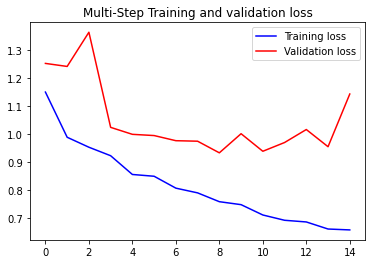

In [ ]:
plot_train_history(multi_step_history, 'Multi-Step Training and validation loss')

Text(0, 0.5, 'class')

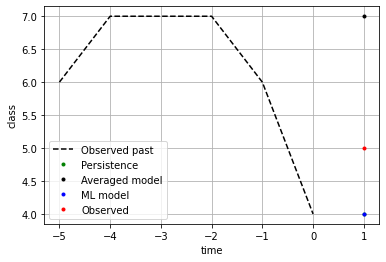

In [ ]:
# Plot some results
ix = np.random.randint(0, len(x_val_vis))

vis = np.expand_dims(x_val_vis[ix,], axis=0)
true_vis = np.expand_dims(y_val_vis[ix,], axis=0)
TTd = np.expand_dims(x_val_TTd[ix,], axis=0)

runs = 20
vis_prob = np.stack([model([vis[:,:,:4], vis[:,:,4], 
                            TTd[:,:,:4], TTd[:,:,4]], training=True) \
                     for sample in range(runs)])
vis_prob = np.argmax(vis_prob, axis=2)

vis_mean = np.round(vis_prob.mean(axis=0))
vis_std = vis_prob.std(axis=0)

# This is the input observations
plt.plot(np.arange(-past_history+1, 1), vis[0,:past_history,4],'k--')

# Persitence prediction
plt.plot(np.arange(1, future_target+1), x_val_vis[ix, past_history-1, 4]*np.ones(future_target),'g.')

# Averaged model prediction
plt.plot(np.arange(1, future_target+1), vis[0,past_history:,4],'k.')

# ML prediction
plt.plot(np.arange(1, future_target+1), vis_mean[0,],'b.')
plt.fill_between(np.arange(1, future_target+1), vis_mean[0,]-vis_std[0,], vis_mean[0,]+vis_std[0,])

# True observed future
plt.plot(np.arange(1, future_target+1), true_vis[0,],'r.')

plt.legend(['Observed past','Persistence','Averaged model','ML model','Observed']) 
plt.grid()
plt.xlabel('time')
plt.ylabel('class')

#for i in range(runs):
#  plt.plot(np.arange(0, future_target), np.round(vis_prob[i,0,]),'r-.')

In [ ]:
# Now verify the model

n_val = len(x_val_vis)

err_pers = np.zeros(n_val)
err_aver = np.zeros(n_val)
err_ml = np.zeros(n_val)

for i in range(n_val):

  # 1) Persistence error
  pers = x_val_vis[i, past_history-1, 4]*np.ones(future_target)
  err_pers[i] = np.mean(np.square(pers - y_val_vis[i,]))

  # 2) Averaged model error
  aver_mod = x_val_vis[i,past_history:, 4]
  err_aver[i] = np.mean(np.square(aver_mod - y_val_vis[i,]))

  # 3) ML model error
  vis = np.expand_dims(x_val_vis[i,], axis=0)
  TTd = np.expand_dims(x_val_TTd[i,], axis=0)
  vis_ml = model([vis[:,:,:4], vis[:,:,4], TTd[:,:,:4], TTd[:,:,4]])
  vis_ml = np.argmax(vis_ml, axis=1)
  err_ml[i] = np.mean(np.square(vis_ml[0,] - y_val_vis[i,]))

print('Persistence error: {}\n'.format(np.sum(err_pers)))
print('Averaged model error: {}\n'.format(np.sum(err_aver)))
print('ML model error: {}\n'.format(np.sum(err_ml)))

Persistence error: 504.0

Averaged model error: 1629.0

ML model error: 618.0

